# 07 · Acceleration process — **NEW / ISOLATED**

**This is NEW work, completely separate from the audited 01–05 ledger.** It uses the Section 12 functions in `sprint_pipeline.py` (`build_accel_feature_table`, `step_spatiotemporal`, `velocity_time_fit`, `fv_profile_samozino`). **It does not replace the honest knee-ROM + height model.** It does not write into `build_feature_table`'s audited `X`, and it does not change notebooks 01–05.

The question here is how the first steps *produce* speed: step length and contact time, and a **mass-free** Samozino / Morin profile (`a0`, `V0`, `tau`, `RFmax`, `DRF`). No body mass is used and none is assumed. Height is **not** scaled to 1.75 m here (that rescale is drawing-only for fPCA skeletons in 01–02). Top-speed *shape* (angles, fPCA) stays in 01–05.

## Pre-specified velocity associations (not a search)

If a scalar is correlated with peak velocity below, it is one of these four, named before looking:

1. mean kinematic contact time (`contact_time_s_mean`)
2. mono-exponential time constant (`tau`)
3. initial modelled acceleration (`a0` = vmax / tau)
4. maximum ratio of forces (`RFmax`)

Permutation tests use `permutation_test` with **n_perm = 5000**. No other acceleration features enter a model in this notebook.

## Units and signs

SI throughout (m, s, m/s, m/s²). No joint angles are modelled here; if any appear they follow the **ISB** convention (knee flexion positive). **Blue = faster.**


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

%matplotlib inline
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)

import sprint_pipeline as SP
from sprint_pipeline import (
    C3D_DIR, EXCLUDED_PIDS, COL_FAST, COL_SLOW,
    clean_for_angles, compute_velocity, peak_velocity_smoothed,
    build_accel_feature_table, step_spatiotemporal,
    com_horizontal_velocity, velocity_time_fit, fv_profile_samozino,
    permutation_test,
)

print(f"{len(sorted(C3D_DIR.glob('*.c3d')))} trials found, excluding {EXCLUDED_PIDS}")
print("Section 12 entry point:", build_accel_feature_table.__name__)


31 trials found, excluding ['SB17']
Section 12 entry point: build_accel_feature_table


## 1 · Ledger invariant (SB25)

The cohort reference run must still be **531 frames** and **8.506 m/s** (raw thoracic peak from `clean_for_angles`). A change here is a regression, not a new result.


In [2]:
sb25 = clean_for_angles("SB25")
print(f"SB25 frames     : {sb25['n_frames']}")
print(f"SB25 peak_vel   : {sb25['peak_vel_ms']:.3f} m/s")
print(f"SB25 fs         : {sb25['fs']} Hz")

assert sb25["n_frames"] == 531, f"REGRESSION: frames={sb25['n_frames']}, expected 531"
assert abs(sb25["peak_vel_ms"] - 8.506) < 5e-4, (
    f"REGRESSION: peak_vel={sb25['peak_vel_ms']:.3f}, expected 8.506"
)
print("SB25 invariant  : 531 frames, 8.506 m/s  OK")


SB25 frames     : 531
SB25 peak_vel   : 8.506 m/s
SB25 fs         : 60 Hz
SB25 invariant  : 531 frames, 8.506 m/s  OK


## 2 · Cohort acceleration-process table

`build_accel_feature_table` is a **separate** table from the audited `X`. No mass is supplied, so `F0` and `Pmax` stay missing.


In [3]:
accel = build_accel_feature_table(n_steps=8, masses=None, verbose=True)
print(f"athletes in accel table: {len(accel)}")
print(f"mass_available any True: {bool(accel['mass_available'].any())}")
print("F0 all missing :", accel["F0"].isna().all() if "F0" in accel else accel["F0"].tolist())
print("Pmax all missing:", accel["Pmax"].isna().all() if "Pmax" in accel else accel["Pmax"].tolist())
display(accel.round(3))


athletes in accel table: 30
mass_available any True: False
F0 all missing : True
Pmax all missing: True


,n_steps,step_length_m_mean,contact_time_s_mean,flight_time_s_mean,step_frequency_hz_mean,step_velocity_ms_mean,slope_step_length_m,slope_contact_time_s,slope_flight_time_s,slope_step_frequency_hz,slope_step_velocity_ms,V0,tau,a0,RFmax,DRF,F0,Pmax,mass_available,fit_ok
SB061,8,1.651,0.079,0.204,4.071,6.731,0.106,-0.015,0.005,0.064,0.533,8.565,0.743,11.521,0.761,-0.105,None,None,False,True
SB101,8,1.461,0.083,0.183,4.552,6.644,0.104,-0.006,0.004,-0.003,0.467,9.240,0.946,9.770,0.706,-0.087,None,None,False,True
SB102,8,1.173,0.112,0.165,4.756,5.496,0.084,-0.007,0.005,-0.125,0.265,7.448,0.867,8.586,0.659,-0.099,None,None,False,True
SB110,8,1.257,0.090,0.188,4.363,5.529,0.061,-0.009,-0.002,0.129,0.411,6.850,0.682,10.050,0.716,-0.121,None,None,False,True
SB111,8,1.448,0.090,0.210,4.155,6.056,0.078,-0.012,-0.013,0.219,0.583,8.140,0.868,9.383,0.691,-0.097,None,None,False,True
SB112,8,1.458,0.081,0.185,4.468,6.479,0.084,-0.016,0.008,-0.047,0.334,8.282,0.844,9.808,0.707,-0.098,None,None,False,True
SB15,8,1.360,0.079,0.194,4.350,5.855,0.089,-0.010,0.011,-0.079,0.296,7.650,0.856,8.941,0.674,-0.100,None,None,False,True
SB150,8,1.481,0.102,0.219,3.747,5.566,0.085,-0.022,0.005,0.109,0.484,7.439,0.928,8.020,0.633,-0.095,None,None,False,True
SB151,8,1.262,0.088,0.185,4.328,5.429,0.079,-0.009,0.004,0.024,0.377,7.411,0.961,7.713,0.618,-0.092,None,None,False,True
SB153,8,1.272,0.092,0.190,4.347,5.545,0.085,-0.014,0.004,0.042,0.405,6.996,0.713,9.812,0.707,-0.117,None,None,False,True


## 3 · SB25: first eight steps, v(t) fit, mass-free FVP

Contact and flight times are kinematic (foot-height band), not force-plate. Alternate-foot contacts are **steps**, not stride-cycle averages.


In [4]:
steps25 = step_spatiotemporal(sb25["mk"], sb25["raw64"], sb25["fs"], n_steps=8)
print("SB25 first 8 steps (SI):")
display(steps25.round(4))

vel_h = com_horizontal_velocity(sb25["raw64"], sb25["fs"])
fit25 = velocity_time_fit(vel_h, sb25["fs"])
fv25 = fv_profile_samozino(vel_h, sb25["fs"], body_mass=None)

print("velocity-time fit  v(t) = vmax * (1 - exp(-t/tau))")
print(f"  vmax = {fit25['vmax']:.3f} m/s   tau = {fit25['tau']:.3f} s   "
      f"a0 = {fit25['a0']:.3f} m/s²   r2 = {fit25['r2']:.3f}   "
      f"rmse = {fit25['rmse']:.3f} m/s   n = {fit25['n_samples']}")
print("mass-free FVP (Samozino / Morin; aero neglected)")
print(f"  V0 = {fv25['V0']:.3f} m/s   RFmax = {fv25['RFmax']:.3f}   DRF = {fv25['DRF']:.4f}")
print(f"  F0 = {fv25['F0']}   Pmax = {fv25['Pmax']}   "
      f"mass_available = {fv25['mass_available']}")
print("F0/Pmax are None without measured body mass — the anthro sheet has no mass column.")


SB25 first 8 steps (SI):


,step,foot,step_length_m,contact_time_s,flight_time_s,step_frequency_hz,step_velocity_ms
0,1,R,1.2692,0.1167,0.2000,3.7500,4.7594
1,2,L,1.2069,0.0667,0.1833,4.6154,5.5703
2,3,R,1.4729,0.1167,0.2500,3.0000,4.4188
3,4,L,1.4676,0.0500,0.2000,4.6154,6.7737
4,5,R,1.5149,0.0667,0.2000,4.2857,6.4923
5,6,L,1.6030,0.0500,0.2000,4.2857,6.8699
6,7,R,1.6521,0.0667,0.2000,4.2857,7.0804
7,8,L,1.7137,0.0833,0.2000,4.2857,7.3446


velocity-time fit  v(t) = vmax * (1 - exp(-t/tau))
  vmax = 7.618 m/s   tau = 0.798 s   a0 = 9.552 m/s²   r2 = 0.840   rmse = 0.595 m/s   n = 531
mass-free FVP (Samozino / Morin; aero neglected)
  V0 = 7.618 m/s   RFmax = 0.698   DRF = -0.1049
  F0 = None   Pmax = None   mass_available = False
F0/Pmax are None without measured body mass — the anthro sheet has no mass column.


## Honest caveats

* **60 Hz contact.** A typical early ground contact is ~80–100 ms, so about **five frames**. Touchdown and toe-off from a 3 cm foot-height band are kinematic estimates to about ±1 frame (~17 ms), not force-plate contact times.
* **vmax is an extrapolation.** In 60 m most athletes have **no velocity plateau**. The mono-exponential `vmax` / `V0` and `tau` describe the captured rise; they are not a measured top speed. The audited peak remains the thoracic 3-D speed (SB25: 8.506 m/s).
* **Pelvis CoM proxy vs thoracic peak.** Horizontal velocity here is the fore-aft gradient of the **seven-marker pelvis cluster**. That is not the 3-D thoracic centroid used for the ledger peak, so `vmax` from the fit and `peak_vel_ms` from `compute_velocity` are different quantities on purpose.
* **Steps, not cycle averages.** Windows are **alternate-foot** contact-to-contact (`find_first_steps`). They are the acceleration *process*, not the top-speed stride cycles of notebooks 01–05.
* **Mass-free by design.** `a0`, `V0`, `tau`, `RFmax` and `DRF` do not need mass (mass cancels). We do **not** fill `F0`/`Pmax` with a dummy kg — that would only rescale `a0`. Newtons/watts are optional conversions, not the analysis.
* **`RFmax` is not a second finding.** `RFmax = a0 / sqrt(a0² + g²)` is a strictly increasing function of `a0`. Report one of them, not both as independent predictors.


## 4 · Pre-specified associations with peak velocity

Target `y` is the **smoothed** thoracic peak (`peak_velocity_smoothed`) — the same class of outcome the 01–05 models use — aligned by pid. This notebook still does **not** replace knee-ROM + height.

Each of the four pre-specified scalars is tested **univariately** with `permutation_test(..., n_perm=5000)`. Pearson *r* is descriptive only.


In [5]:
# Peak velocity for the same pids (does not call or mutate build_feature_table).
y_raw, y_sm = {}, {}
for fpath in sorted(C3D_DIR.glob("*.c3d")):
    pid = fpath.stem.split("-")[0].strip()
    if pid in EXCLUDED_PIDS or pid not in accel.index:
        continue
    tr = clean_for_angles(fpath)
    y_raw[pid] = tr["peak_vel_ms"]
    v_raw, _, _ = compute_velocity(tr["mk"], tr["fs"], raw64=tr["raw64"])
    y_sm[pid] = float(peak_velocity_smoothed(v_raw)[0])

# Re-state the invariant from this second load (same function, same file).
print(f"SB25 from peak-vel pass: {y_raw['SB25']:.3f} m/s raw, "
      f"{y_sm['SB25']:.3f} m/s smoothed  |  frames already asserted 531")

pids = [p for p in accel.index if p in y_sm]
y = np.array([y_sm[p] for p in pids], dtype=float)
print(f"n athletes in pre-specified tests: {len(pids)}")

PRE_SPECIFIED = [
    ("contact_time_s_mean", "mean kinematic contact time (s)"),
    ("tau", "mono-exponential tau (s)"),
    ("a0", "initial modelled acceleration a0 (m/s²)"),
    ("RFmax", "maximum ratio of forces (dimensionless)"),
]

rows = []
nulls = {}
for col, label in PRE_SPECIFIED:
    x = accel.loc[pids, col].to_numpy(dtype=float)
    mask = np.isfinite(x) & np.isfinite(y)
    X = x[mask].reshape(-1, 1)
    yy = y[mask]
    r = float(np.corrcoef(X[:, 0], yy)[0, 1]) if mask.sum() >= 3 else np.nan
    obs_r2, p_perm, null = permutation_test(X, yy, n_perm=5000, seed=1)
    nulls[col] = (obs_r2, p_perm, null)
    rows.append({
        "feature": col,
        "label": label,
        "n": int(mask.sum()),
        "pearson_r": r,
        "LOO_R2": obs_r2,
        "p_perm_5000": p_perm,
    })
    print(f"{col:<22} r = {r:+.3f}   LOO R2 = {obs_r2:+.3f}   "
          f"p (5000 shuffles) = {p_perm:.4f}   n = {mask.sum()}")

assoc = pd.DataFrame(rows)
display(assoc.round(4))


SB25 from peak-vel pass: 8.506 m/s raw, 8.103 m/s smoothed  |  frames already asserted 531
n athletes in pre-specified tests: 30


contact_time_s_mean    r = -0.308   LOO R2 = +0.001   p (5000 shuffles) = 0.0542   n = 30


tau                    r = +0.106   LOO R2 = -0.129   p (5000 shuffles) = 0.5655   n = 30


a0                     r = +0.657   LOO R2 = +0.356   p (5000 shuffles) = 0.0004   n = 30


RFmax                  r = +0.680   LOO R2 = +0.391   p (5000 shuffles) = 0.0002   n = 30


,feature,label,n,pearson_r,LOO_R2,p_perm_5000
0,contact_time_s_mean,mean kinematic contact time (s),30,-0.3080,0.0014,0.0542
1,tau,mono-exponential tau (s),30,0.1063,-0.1291,0.5655
2,a0,initial modelled acceleration a0 (m/s²),30,0.6568,0.3557,0.0004
3,RFmax,maximum ratio of forces (dimensionless),30,0.6799,0.3911,0.0002


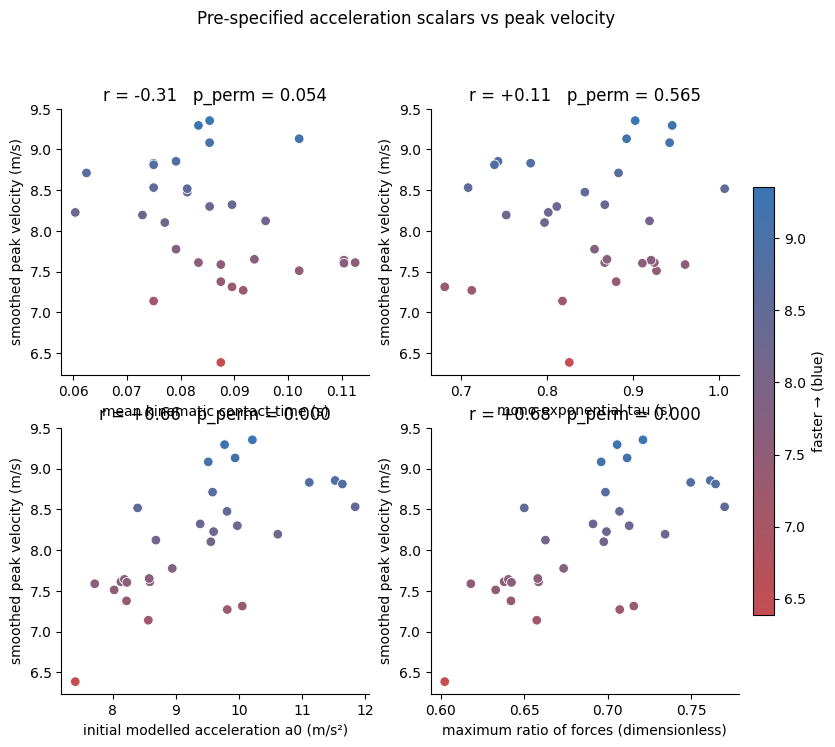

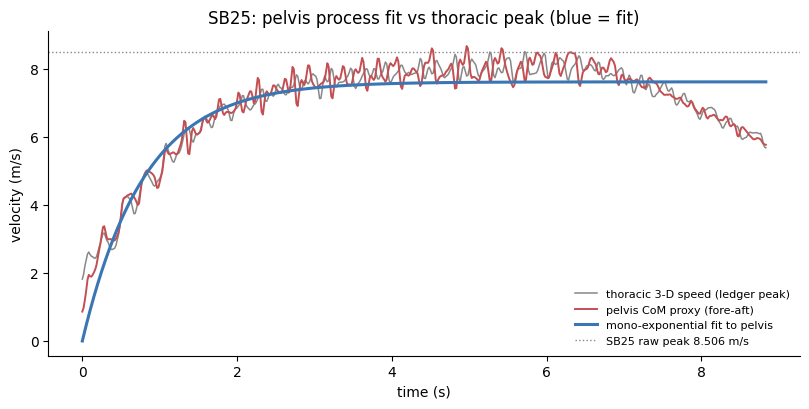

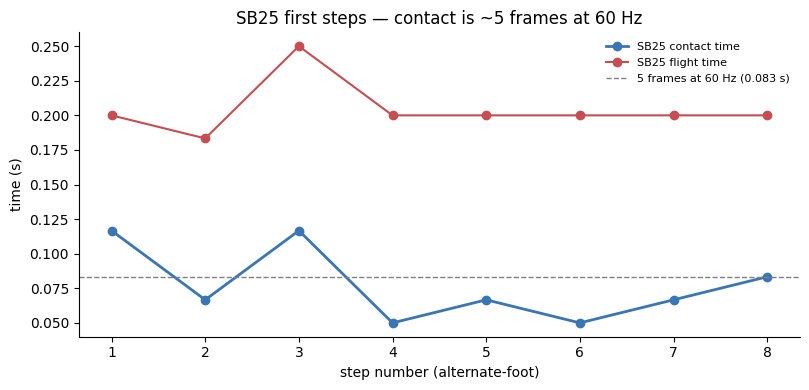

In [6]:
# Colour: red = slower, blue = faster (COL_SLOW → COL_FAST).
cmap_speed = LinearSegmentedColormap.from_list(
    "slow_fast", [COL_SLOW, COL_FAST]
)
v_colour = np.array([y_sm[p] for p in pids])

fig, axes = plt.subplots(2, 2, figsize=(9.2, 7.6))
for ax, (col, label) in zip(axes.ravel(), PRE_SPECIFIED):
    x = accel.loc[pids, col].to_numpy(dtype=float)
    sc = ax.scatter(x, y, c=v_colour, cmap=cmap_speed, s=48,
                    edgecolor="white", linewidth=0.6, zorder=3)
    ax.set_xlabel(label)
    ax.set_ylabel("smoothed peak velocity (m/s)")
    r = assoc.loc[assoc["feature"] == col, "pearson_r"].iloc[0]
    p = assoc.loc[assoc["feature"] == col, "p_perm_5000"].iloc[0]
    ax.set_title(f"r = {r:+.2f}   p_perm = {p:.3f}")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

cbar = fig.colorbar(sc, ax=axes.ravel().tolist(), fraction=0.03, pad=0.02)
cbar.set_label("faster → (blue)")
fig.suptitle("Pre-specified acceleration scalars vs peak velocity", y=1.01)
plt.show()

# SB25 v(t) fit: pelvis CoM proxy (process) vs thoracic 3-D speed (ledger).
t = np.arange(len(vel_h)) / sb25["fs"]
v_thor, _, _ = compute_velocity(sb25["mk"], sb25["fs"], raw64=sb25["raw64"])
v_hat = fit25["vmax"] * (1.0 - np.exp(-t / fit25["tau"]))

fig, ax = plt.subplots(figsize=(8.2, 4.2))
ax.plot(t, v_thor, color="#888888", lw=1.1, label="thoracic 3-D speed (ledger peak)")
ax.plot(t, vel_h, color=COL_SLOW, lw=1.4, label="pelvis CoM proxy (fore-aft)")
ax.plot(t, v_hat, color=COL_FAST, lw=2.2, label="mono-exponential fit to pelvis")
ax.axhline(8.506, color="#888888", ls=":", lw=1, label="SB25 raw peak 8.506 m/s")
ax.set_xlabel("time (s)")
ax.set_ylabel("velocity (m/s)")
ax.set_title("SB25: pelvis process fit vs thoracic peak (blue = fit)")
ax.legend(frameon=False, fontsize=8)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8.2, 4.0))
ax.plot(steps25["step"], steps25["contact_time_s"],
        color=COL_FAST, marker="o", lw=2, label="SB25 contact time")
ax.plot(steps25["step"], steps25["flight_time_s"],
        color=COL_SLOW, marker="o", lw=1.5, label="SB25 flight time")
ax.axhline(5 / sb25["fs"], color="0.5", ls="--", lw=1,
           label="5 frames at 60 Hz (%.3f s)" % (5 / sb25["fs"]))
ax.set_xlabel("step number (alternate-foot)")
ax.set_ylabel("time (s)")
ax.set_title("SB25 first steps — contact is ~5 frames at 60 Hz")
ax.legend(frameon=False, fontsize=8)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()


## Mass-free is the analysis

No measured mass, and no assumed 72 kg. The profile this notebook stands on is `a0`, `V0`, `tau`, `RFmax`, `DRF`. `F0` (N) and `Pmax` (W) remain unused. OpenSim IK angles in notebook 06 are also mass-free; swing-phase moments there are generic-mass *shapes* only.


## 5 · Mass-free: a0 vs RFmax, then vs the audited model

`RFmax` is a strictly increasing function of `a0`, so they must not be treated as two mechanisms. The useful question is whether **a0** (mass-free initial acceleration of the pelvis v(t) rise) adds anything beside the audited **knee ROM + height** model. Height here is *measured stature*, not the 1.75 m drawing scale. No mass is used.

In [ ]:
from sprint_pipeline import build_feature_table, model_ladder, permutation_test

r_a0_rf = float(np.corrcoef(accel["a0"].astype(float),
                            accel["RFmax"].astype(float))[0, 1])
print(f"a0 vs RFmax  Pearson r = {r_a0_rf:+.4f}   (expected near +1; not two findings)")

print("loading audited scalar table (does not write into accel) ...")
ft = build_feature_table(verbose=True)
common = accel.index.intersection(ft["X"].index).intersection(ft["y"].index)
print(f"aligned n = {len(common)}")

y = ft["y"].loc[common].to_numpy(dtype=float)
a0 = accel.loc[common, ["a0"]].to_numpy(dtype=float)
height = ft["height"].loc[common].to_numpy(dtype=float).reshape(-1, 1)
knee = ft["X"].loc[common, ["knee_hi_ROM", "knee_lo_ROM"]].to_numpy(dtype=float)

specs = [
    ("intercept only", np.ones((len(common), 1)), None, None),
    ("a0 (mass-free)", a0, None, None),
    ("height only", height, None, None),
    ("knee ROM (hi + lo)", knee, None, None),
    ("knee ROM + height (audited)", np.hstack([knee, height]), None, None),
    ("a0 + height", np.hstack([a0, height]), None, None),
    ("a0 + knee ROM + height", np.hstack([a0, knee, height]), None, None),
]
print("LOO ladder (mass-free a0 vs audited knee + height)")
ladder, _preds = model_ladder(specs, y, verbose=True)

obs_r2, p_a0, _null = permutation_test(a0, y, n_perm=5000, seed=0)
print(f"a0-only permutation: LOO R2 = {obs_r2:+.3f}   p = {p_a0:.4f}   n_perm = 5000")
ladder

**Recomputed this session (n = 30, LOO, 5,000 shuffles).** `a0` vs `RFmax` r = **+0.995** — one finding, not two.

| model | LOO R² | RMSE (m/s) |
|---|---|---|
| intercept only | −0.070 | 0.735 |
| **a0 (mass-free)** | **+0.356** (p = 0.0004) | 0.571 |
| height only | +0.097 | 0.675 |
| knee ROM (hi + lo) | +0.220 | 0.628 |
| knee ROM + height *(audited)* | +0.256 | 0.613 |
| **a0 + height** | **+0.405** (p = 0.0002) | 0.549 |
| a0 + knee ROM + height | +0.390 | 0.555 |

Mass-free `a0` out-predicts the audited knee+height model on its own. Adding knee ROM on top of `a0` + height does **not** help (0.390 < 0.405). This does not replace the ledger: `a0` is a *process* summary of the velocity rise, so it is closer to the outcome than a joint angle is. SB25 invariant still 531 frames / 8.506 m/s. No mass used. Re-run the cell above to refresh the numbers.